In [47]:
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
import astropy.constants as constants

from scipy.interpolate import interp1d

import jax
import jax.numpy as jnp

import numpy as np
import pandas as pd

import h5py

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

In [152]:
# load injection data
def read_data(file: str, gwtc_version: int) -> pd.DataFrame:
    # Load
    raw_injection_data = h5py.File(file, 'r')
    # injections now called events in gwtc4
    if gwtc_version == 3:
        events = raw_injection_data['injections']
        m1_key, m2_key, dist_key, redshift_key = "mass1", "mass2", "distance", "redshift"
    elif gwtc_version == 4:
        events = raw_injection_data["events"]
        m1_key, m2_key, dist_key, redshift_key = "mass1_detector", "mass2_detector", "luminosity_distance", "z"
    print("Data length:", len(events))

    # Read injection parameters
    injectionData = pd.DataFrame()
    injectionData['m1_detector'] = np.array(events[m1_key][()], dtype='float64')
    injectionData['m2_detector'] = np.array(events[m2_key][()], dtype='float64')
    injectionData['luminosity_distance'] = events[dist_key][()]/1000.  # Convert from Mpc to Gpc
    injectionData['right_ascension'] = events['right_ascension']
    injectionData['declination'] = events['declination']
    injectionData['polarization'] = events['polarization']
    injectionData['inclination'] = events['inclination']
    injectionData['tilt1'] = events['spin1_polar_angle']
    injectionData['tilt2'] = events['spin2_polar_angle']
    injectionData['phi1'] = events['spin1_azimuthal_angle']
    injectionData['phi2'] = events['spin2_azimuthal_angle']
    
    injectionData['redshift'] = events[redshift_key][()]

    injectionData['cos_polarization'] = np.cos(events['polarization'])
    injectionData['cos_right_ascension'] = np.cos(events['right_ascension'])
    injectionData['cos_inclination'] = np.cos(events['inclination'])
    injectionData['cos_phi1'] = np.cos(events['spin1_azimuthal_angle'])
    injectionData['cos_phi2'] = np.cos(events['spin2_azimuthal_angle'])

    # add source-frame quantities
    injectionData["m1_source"] = injectionData['m1_detector'] / (1 + injectionData['redshift'])
    injectionData["m2_source"] = injectionData['m2_detector'] / (1 + injectionData['redshift'])
    
    # Some derived mass parameters
    injectionData['q'] = injectionData.m2_detector/injectionData.m1_detector
    injectionData['eta'] = injectionData.m1_detector*injectionData.m2_detector/(injectionData.m1_detector+injectionData.m2_detector)**2
    injectionData['chirp_mass_detector'] = injectionData.eta**(3./5.)*(injectionData.m1_detector+injectionData.m2_detector)
    injectionData['total_mass_detector'] = (injectionData.m1_detector+injectionData.m2_detector)

    # And some derived spin parameters
    s1x = np.array(events['spin1x'])
    s1y = np.array(events['spin1y'])
    s1z = np.array(events['spin1z'])
    s2x = np.array(events['spin2x'])
    s2y = np.array(events['spin2y'])
    s2z = np.array(events['spin2z'])
    injectionData['s1x'] = s1x
    injectionData['s1y'] = s1y
    injectionData['s1z'] = s1z
    injectionData['s2x'] = s2x
    injectionData['s2y'] = s2y
    injectionData['s2z'] = s2z
    injectionData['a1'] = np.sqrt(s1x**2 + s1y**2 + s1z**2)
    injectionData['a2'] = np.sqrt(s2x**2 + s2y**2 + s2z**2)
    injectionData['cost1'] = s1z/injectionData.a1
    injectionData['cost2'] = s2z/injectionData.a2
    injectionData['Xeff'] = (s1z + injectionData.q*s2z)/(1.+injectionData.q)
    injectionData['Xdiff'] = (s1z - injectionData.q*s2z)/(1.+injectionData.q)

    # sint1 = np.sqrt(1-injectionData.cost1**2)
    # sint2 = np.sqrt(1-injectionData.cost2**2)

    # injectionData['cos_phi1'] = (s1x / (injectionData.a1*sint1))
    # injectionData['cos_phi2'] = (s2x / (injectionData.a2*sint2))

    # injectionData["phi1"] = np.arccos(injectionData['cos_phi1'])
    # injectionData["phi2"] = np.arccos(injectionData['cos_phi2'])
    # injectionData['Xp_gen'] = generalized_Xp(s1x, s1y, s2x,  s2y, injectionData.q)

    # transforming data for NF (making it nearly Gaussian or similarly well distributed)
    injectionData['sinusoidal_right_ascension'] = np.arccos(1 - injectionData.right_ascension / np.pi)
    injectionData['sinusoidal_polarization'] = np.arccos(1 - 2*injectionData.polarization / np.pi)

    injectionData["t1"] = np.arccos(injectionData.cost1)
    injectionData["t2"] = np.arccos(injectionData.cost2)

    # injectionData["sinusoidal_phi1"] = np.arccos(1 - 2 * np.arccos(injectionData.cos_phi1) / np.pi)
    # injectionData["sinusoidal_phi2"] = np.arccos(1 - 2 * np.arccos(injectionData.cos_phi2) / np.pi)
    
    if gwtc_version == 4:
        #changed in GWTC4
        far_min = np.min([events['%s_far'%search][:] for search in raw_injection_data.attrs['searches']], axis=0)

        injectionData["p_draw_m1"] = np.exp(events["lnpdraw_mass1_source"])
        injectionData["p_draw_m2"] = np.exp(events["lnpdraw_mass2_source_GIVEN_mass1_source"])

        injectionData["p_draw_a1"] = np.exp(events["lnpdraw_spin1_magnitude"])
        injectionData["p_draw_a2"] = np.exp(events["lnpdraw_spin2_magnitude"])

        injectionData["p_draw_ra"] = np.exp(events["lnpdraw_right_ascension"])
        injectionData["p_draw_dec"] = np.exp(events["lnpdraw_declination"])

        injectionData["p_draw_inc"] = np.exp(events["lnpdraw_inclination"])
        injectionData["p_draw_pol"] = np.exp(events["lnpdraw_polarization"])

        injectionData["p_draw_phi1"] = np.exp(events["lnpdraw_spin1_azimuthal_angle"])
        injectionData["p_draw_phi2"] = np.exp(events["lnpdraw_spin2_azimuthal_angle"])

        injectionData["p_draw_tilt1"] = np.exp(events["lnpdraw_spin1_polar_angle"])
        injectionData["p_draw_tilt2"] = np.exp(events["lnpdraw_spin2_polar_angle"])

        injectionData["p_draw_z"] = np.exp(events["lnpdraw_z"])

        # injectionData['p_draw'] = np.exp(raw_injection_data['lnpdraw_mass1_source_mass2_source_redshift_spin1x_spin1y_spin1z_spin2x_spin2y_spin2z'][:]) # /(1+injectionData['redshift'])**2/ddL_of_z(injectionData['redshift'],injectionData['luminosity_distance'],H0cosmo)
        # T = (raw_injection_data.attrs['total_analysis_time'])/(3600.0*24.0*365.25) 
        # injectionData['p_draw'] /= T
        
        injectionData['weights'] = events['weights'][()]
        
    injectionData['far_min'] = far_min
    injectionData['detected'] = np.where(far_min < 1, 1, 0)
    print("Number of detected injections:", np.sum(injectionData['detected']))

    return injectionData

In [153]:
fname = Path("/project/ls-gruen/users/julius.gassert/data/samples-rpo4a_v2_20250503133839UTC-1366933504-23846400.hdf")

In [154]:
with h5py.File(fname, "r") as obj:
    events = obj["events"][:]
    meta = dict(obj.attrs.items())

In [155]:
events.dtype

dtype([('fref', '<f8'), ('lnpdraw_z', '<f8'), ('snr_flow', '<f8'), ('polarization', '<f8'), ('mass1_detector', '<f8'), ('lnpdraw_declination', '<f8'), ('spin2x', '<f8'), ('dluminosity_distance_dredshift', '<f8'), ('spin1x', '<f8'), ('lnpdraw_eccentricity', '<f8'), ('eccentricity', '<f8'), ('time_geocenter', '<f8'), ('spin2z', '<f8'), ('observed_snr_net', '<f8'), ('mass2_source', '<f8'), ('lnpdraw_spin2_magnitude', '<f8'), ('declination', '<f8'), ('spin2_polar_angle', '<f8'), ('mass1_source', '<f8'), ('spin2_magnitude', '<f8'), ('time_H', '<f8'), ('q', '<f8'), ('snr_H', '<f8'), ('waveform_flow', '<f8'), ('spin1_polar_angle', '<f8'), ('observed_phase_maximized_snr_net', '<f8'), ('observed_snr_H', '<f8'), ('lnpdraw_spin1_magnitude', '<f8'), ('spin1_azimuthal_angle', '<f8'), ('lnpdraw_spin2_azimuthal_angle', '<f8'), ('snr_net', '<f8'), ('lnpdraw_mass1_source', '<f8'), ('mass2_detector', '<f8'), ('spin1_magnitude', '<f8'), ('spin1z', '<f8'), ('waveform_tref', '<f8'), ('lnpdraw_spin1_azimuth

In [156]:
data = read_data(fname, 4)

Data length: 1499244
Number of detected injections: 476406


In [157]:
data

,m1_detector,m2_detector,luminosity_distance,right_ascension,declination,polarization,inclination,tilt1,tilt2,phi1,...,p_draw_inc,p_draw_pol,p_draw_phi1,p_draw_phi2,p_draw_tilt1,p_draw_tilt2,p_draw_z,weights,far_min,detected
0,87.680089,56.912638,4.007806,5.002674,-0.254790,0.614705,1.573441,1.346254,0.404648,4.303158,...,0.499998,0.31831,0.159155,0.159155,0.474854,0.346536,0.196423,0.804290,inf,0
1,54.408109,49.680587,2.381053,0.409010,-0.917783,0.058546,2.081814,0.957176,0.501396,3.971911,...,0.436124,0.31831,0.159155,0.159155,0.526096,0.406582,0.107224,0.804290,inf,0
2,51.668975,20.366343,2.690371,5.263240,-0.698737,2.663313,0.425729,2.234633,0.852469,3.663590,...,0.206492,0.31831,0.159155,0.159155,0.279013,0.520946,0.125065,0.804290,inf,0
3,102.782254,86.531760,3.907749,3.848270,-0.599299,0.296581,0.518585,1.671130,0.662741,5.424429,...,0.247826,0.31831,0.159155,0.159155,0.402610,0.479261,0.191349,0.804290,inf,0
4,40.381354,34.546820,3.611020,2.204904,1.053326,2.647054,0.512992,1.446252,1.558749,4.103694,...,0.245393,0.31831,0.159155,0.159155,0.453030,0.427712,0.175935,0.804290,inf,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1499239,42.069507,27.655349,1.836552,5.592748,1.044990,0.352504,2.479280,1.800141,2.533089,1.943266,...,0.307471,0.31831,0.159155,0.159155,0.374526,0.200322,0.075638,1.130915,inf,0
1499240,141.587869,108.244782,9.694232,0.428992,1.191597,0.822922,2.543763,1.598731,1.991064,5.469213,...,0.281425,0.31831,0.159155,0.159155,0.418726,0.333749,0.385890,1.130915,inf,0
1499241,101.335786,100.248667,4.904618,3.778430,-0.948454,1.955454,0.540291,0.509533,2.018699,3.444544,...,0.257193,0.31831,0.159155,0.159155,0.411084,0.327793,0.239008,1.130915,inf,0
1499242,4.701713,3.397398,0.335602,0.864340,0.470035,0.662202,2.036291,2.353646,0.194585,6.147378,...,0.446800,0.31831,0.159155,0.159155,0.249478,0.180438,0.004544,1.130915,inf,0


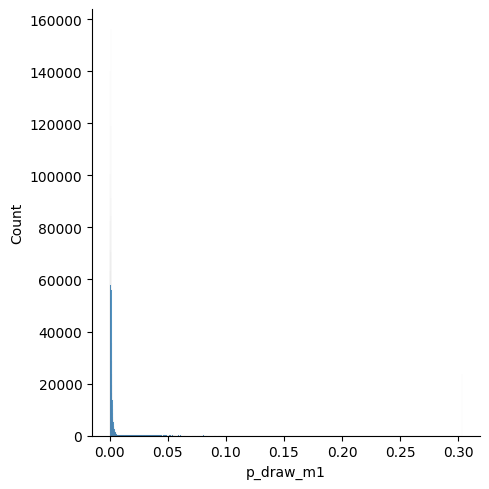

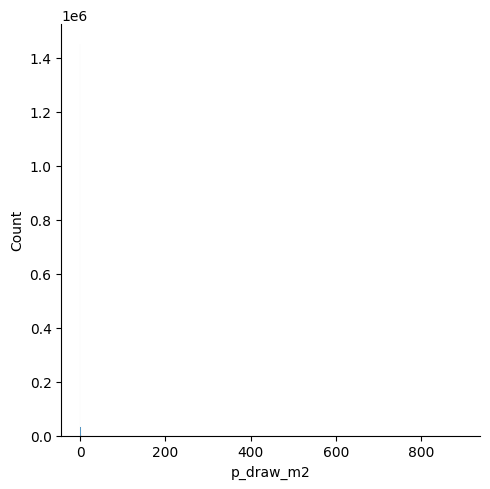

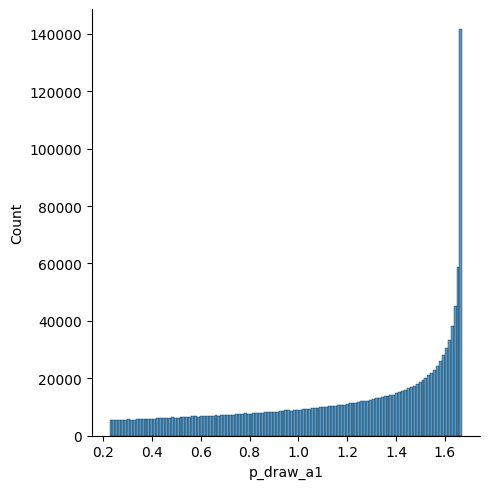

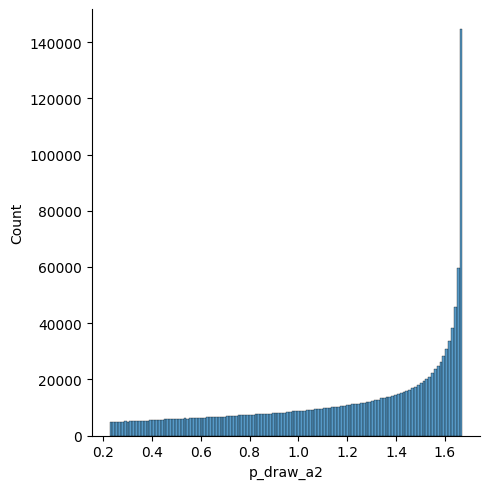

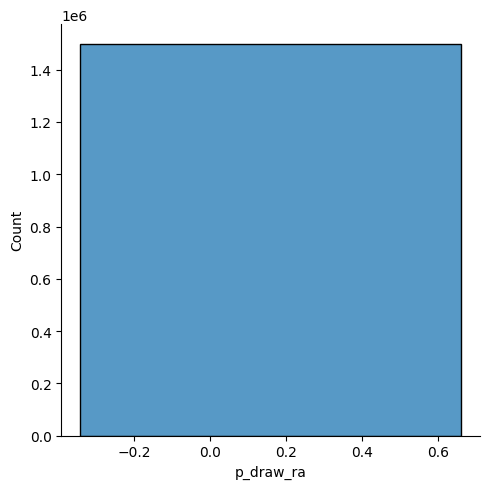

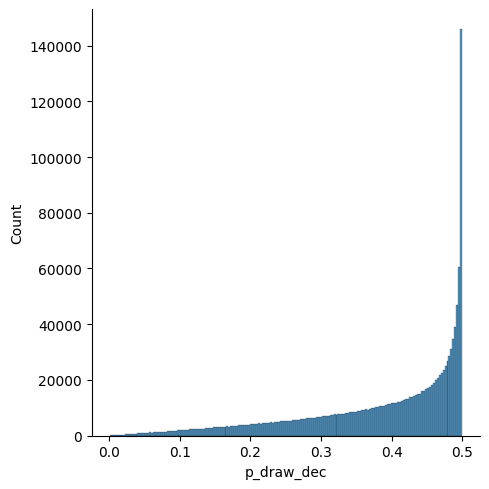

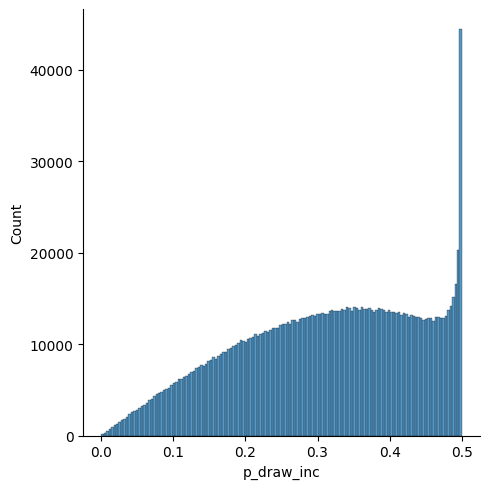

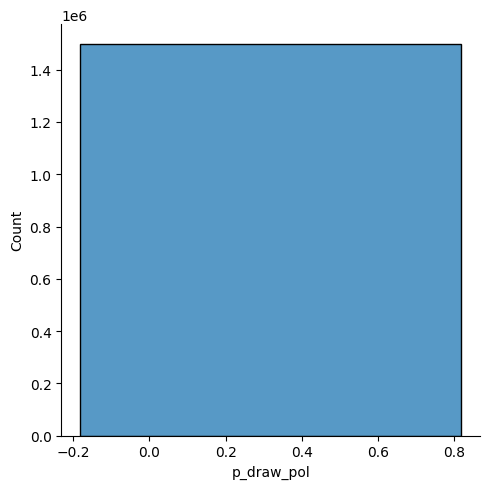

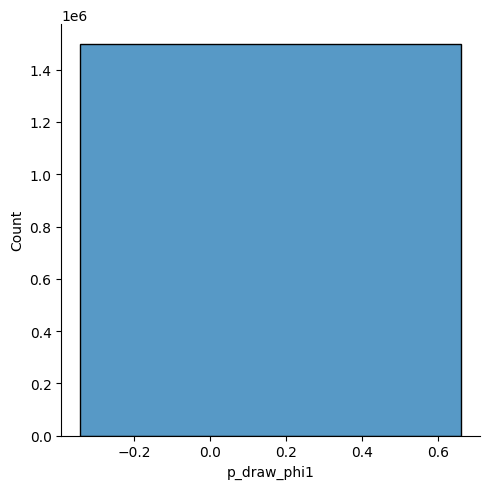

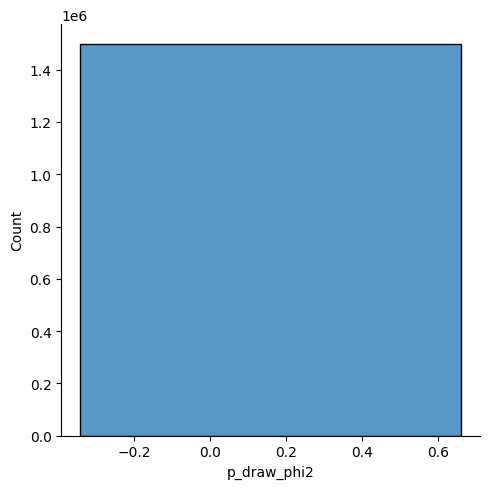

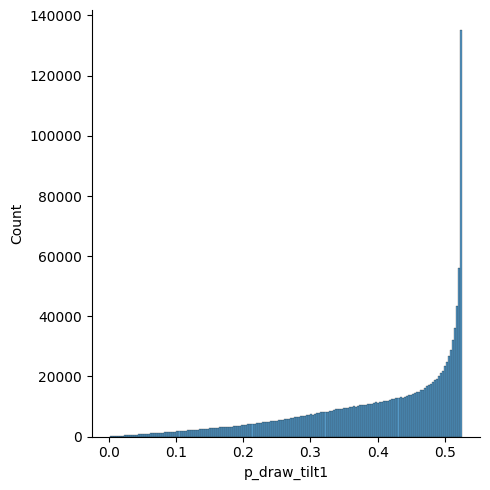

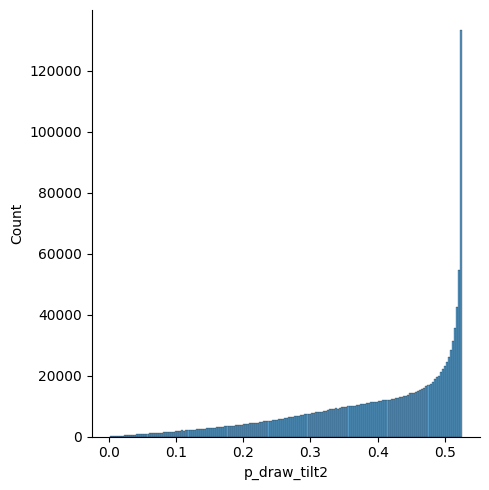

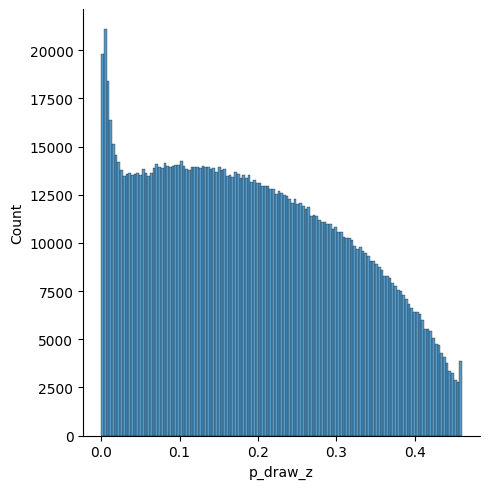

In [38]:
for col in data.columns:
    if "draw" in col:
        sns.displot(data[col])
        plt.show()

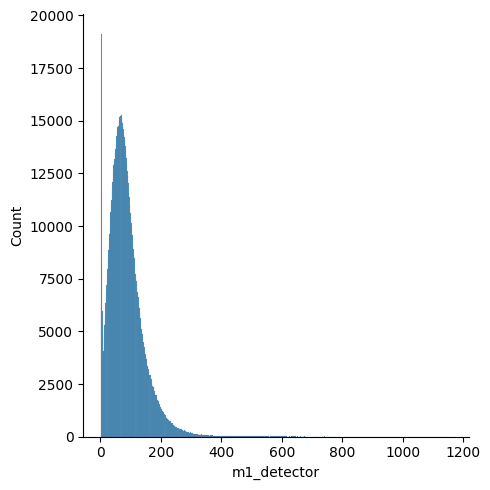

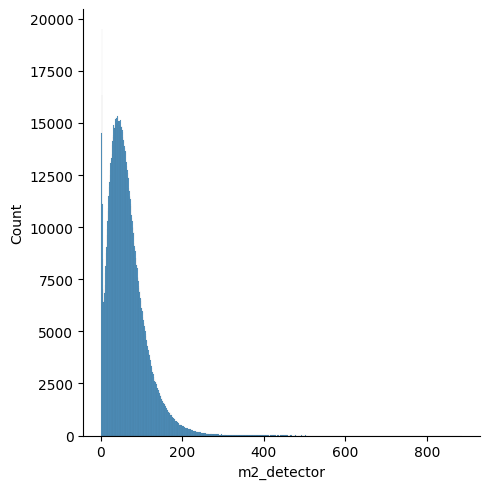

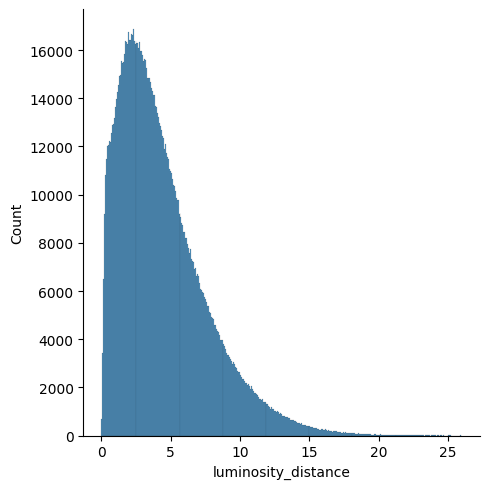

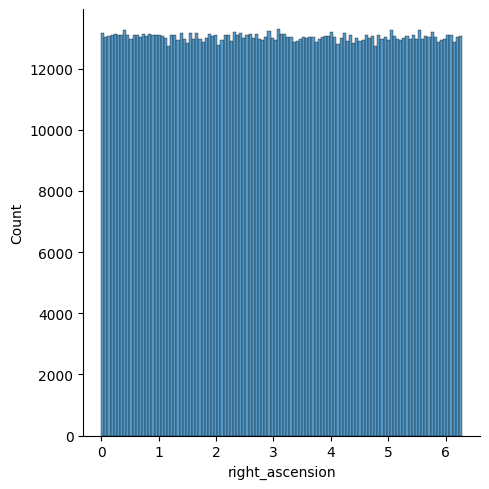

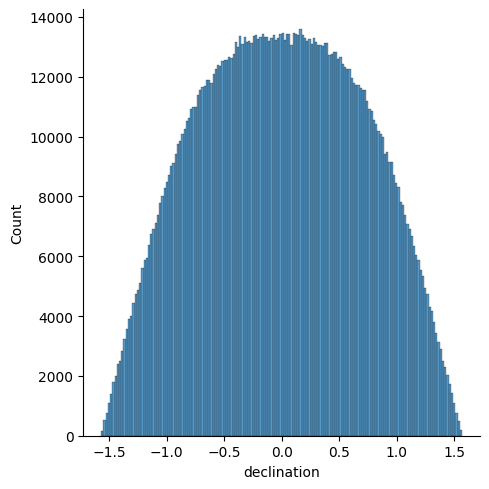

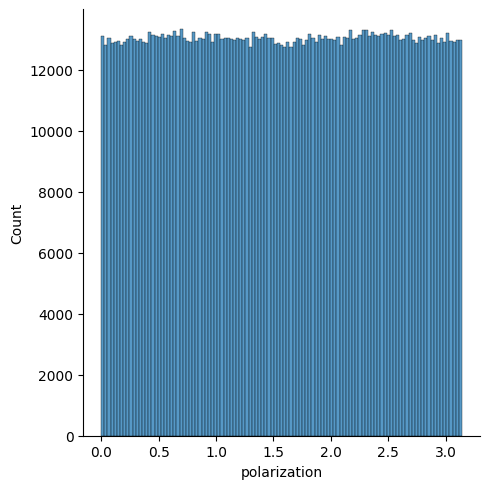

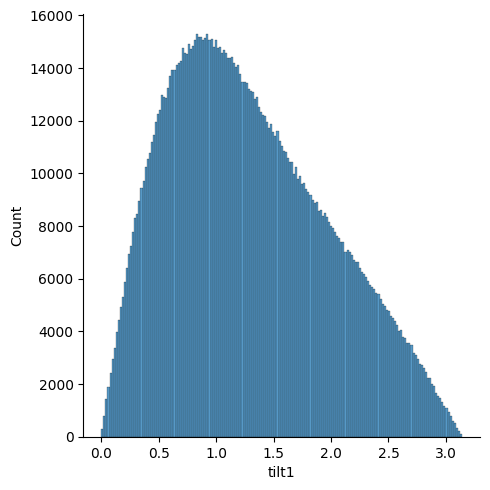

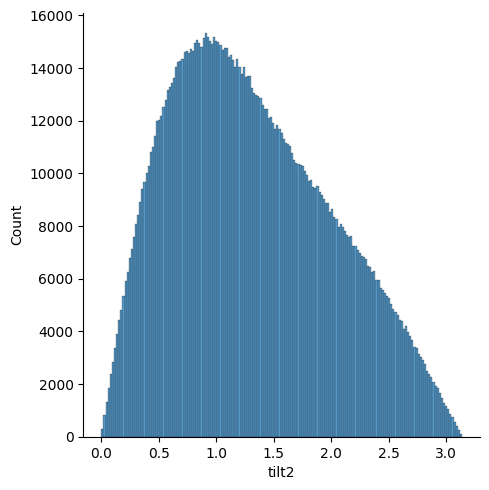

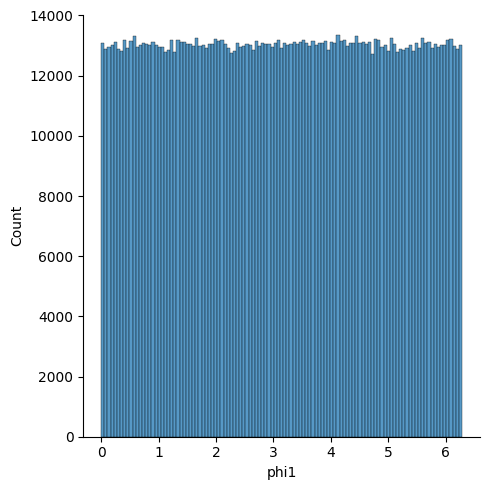

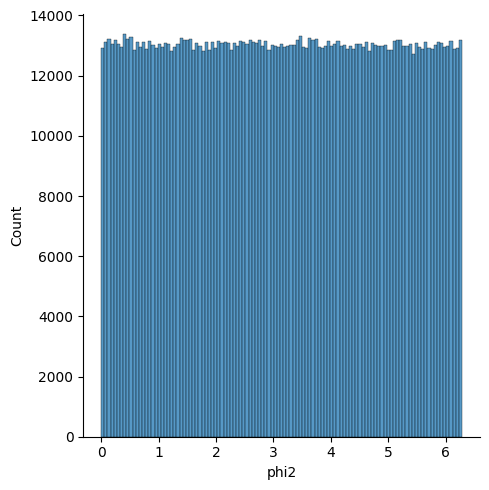

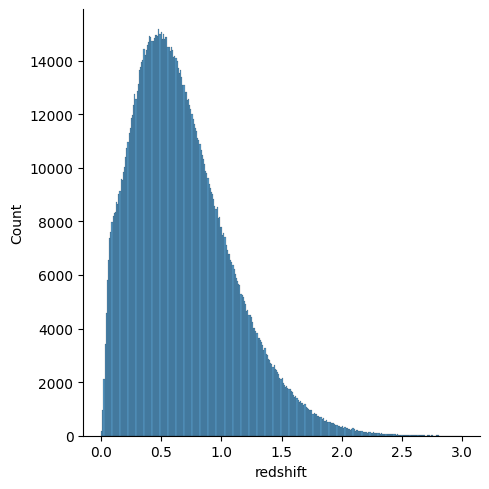

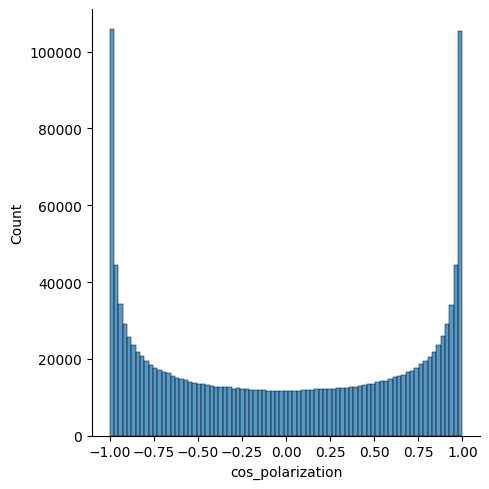

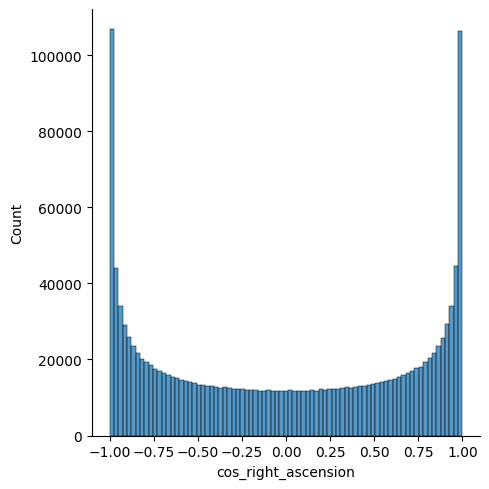

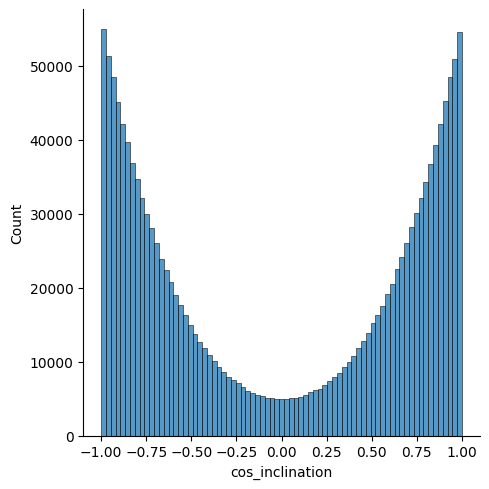

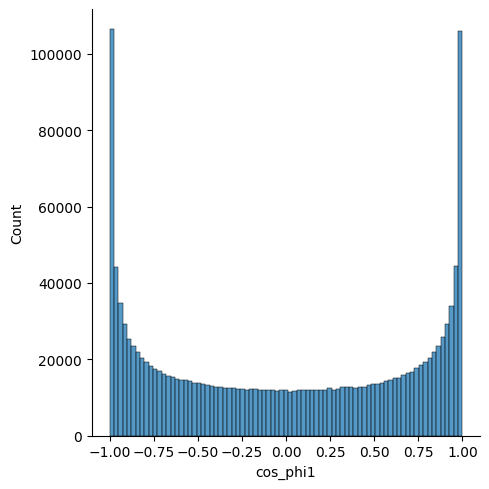

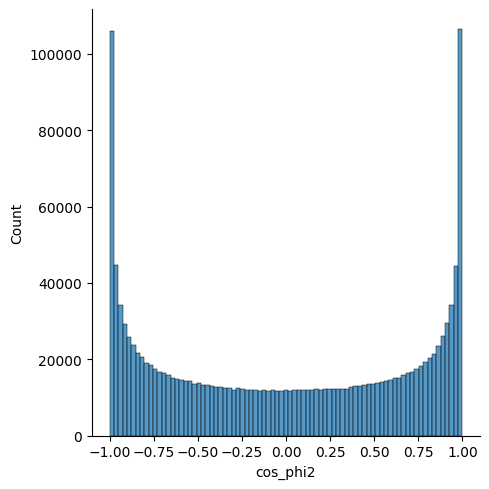

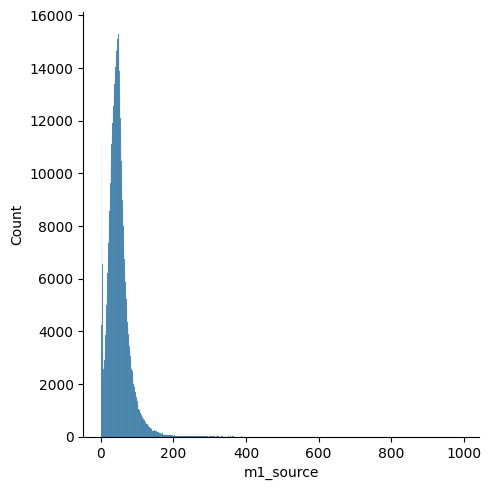

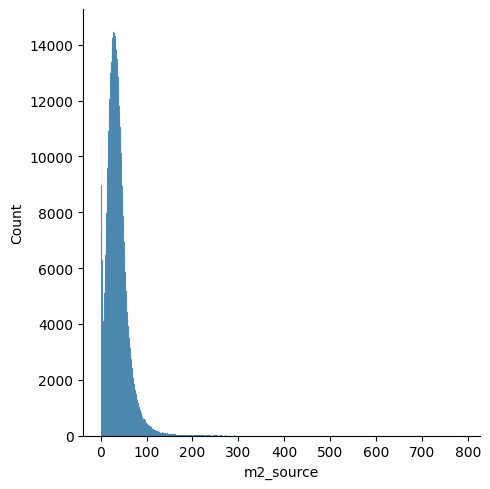

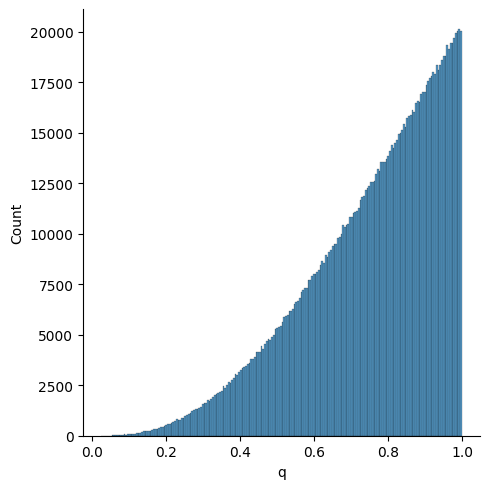

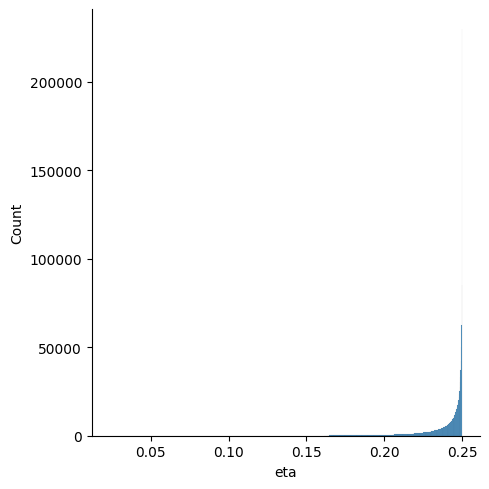

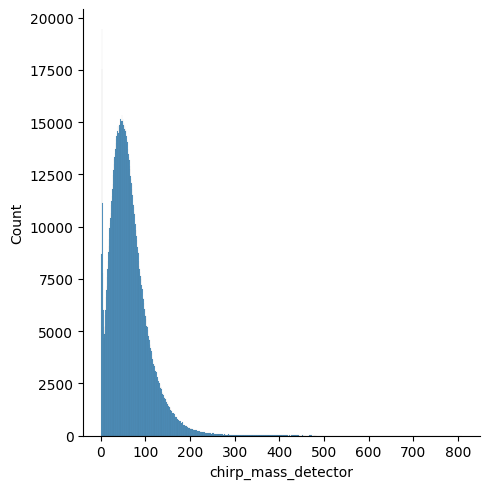

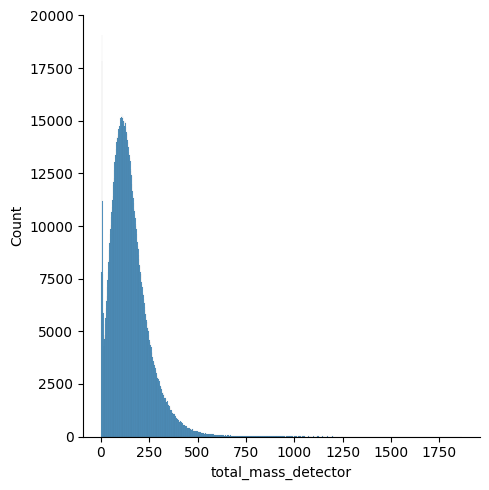

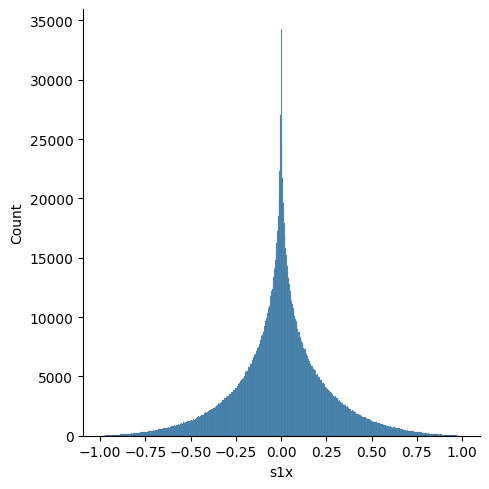

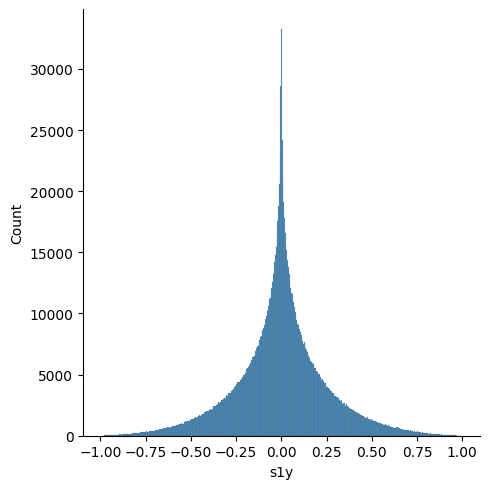

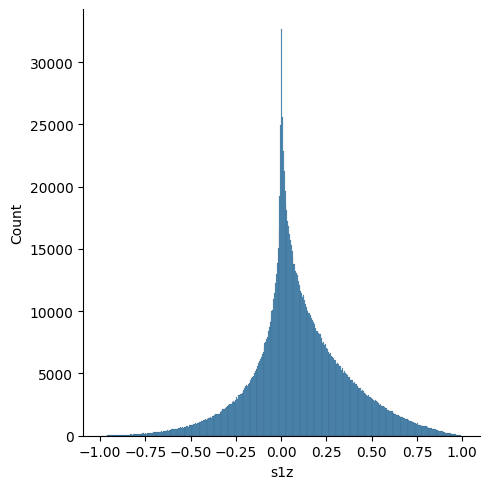

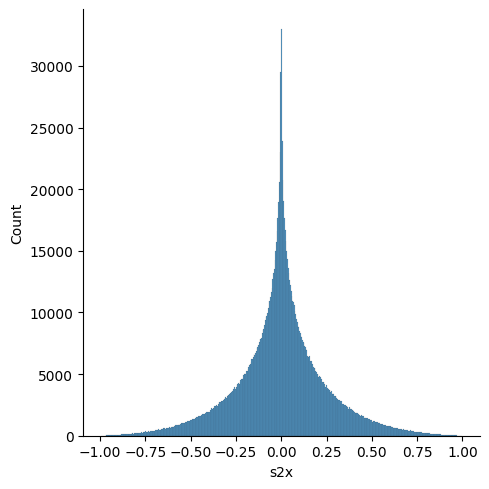

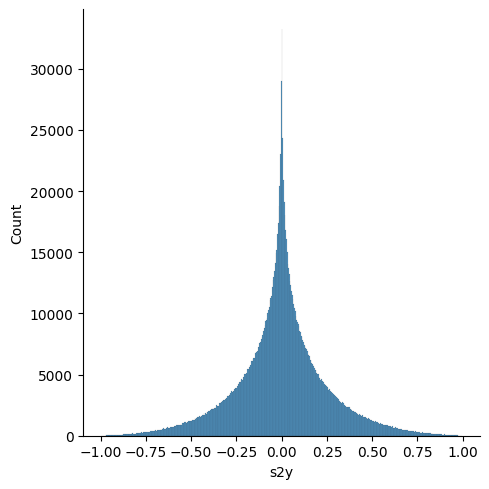

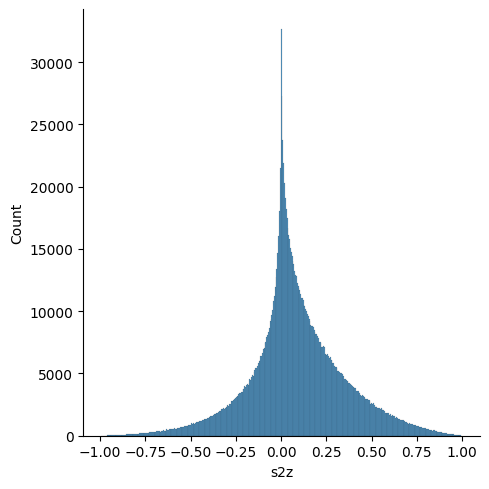

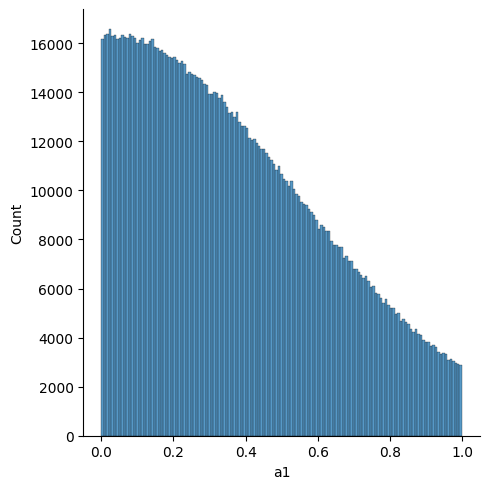

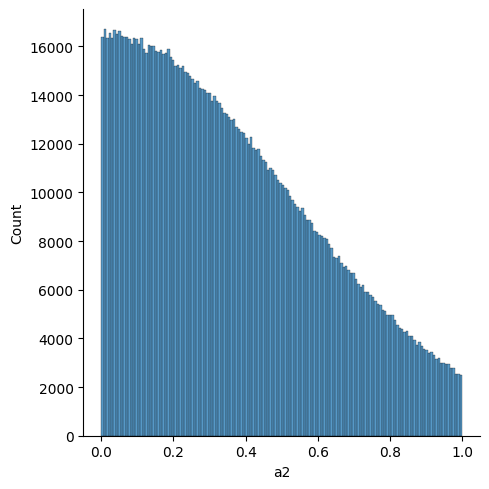

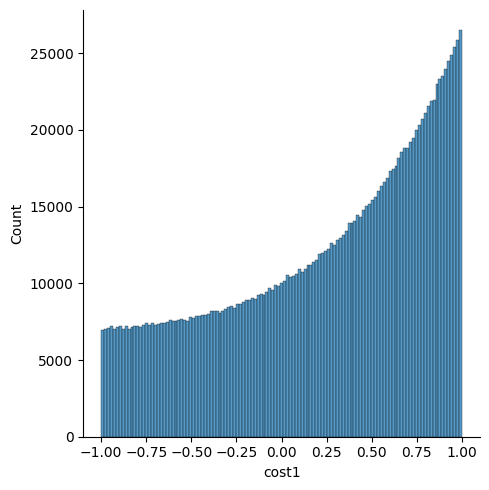

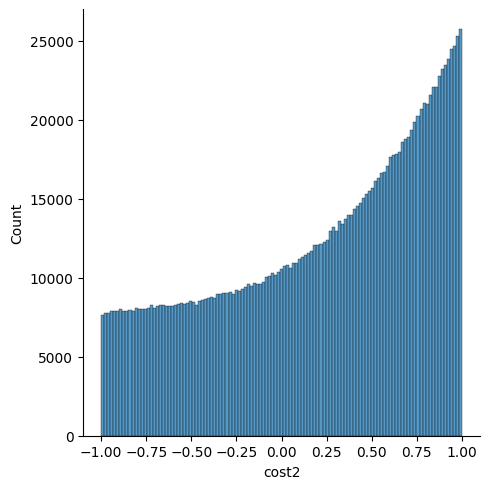

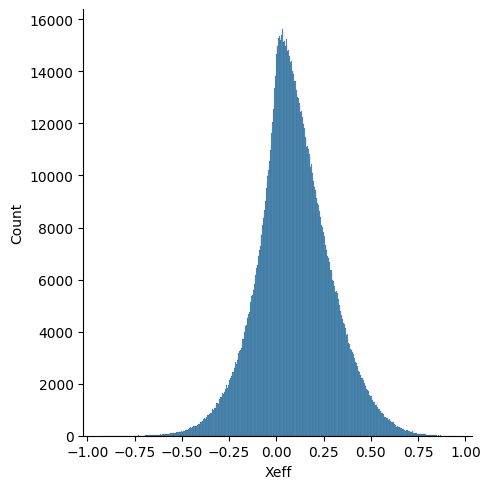

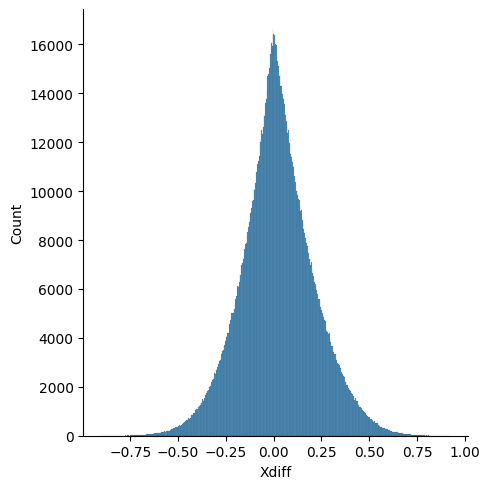

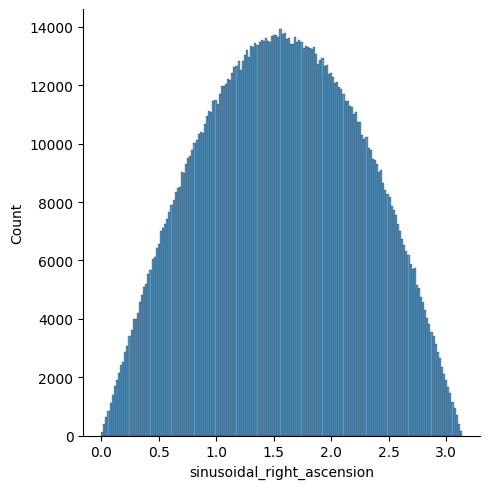

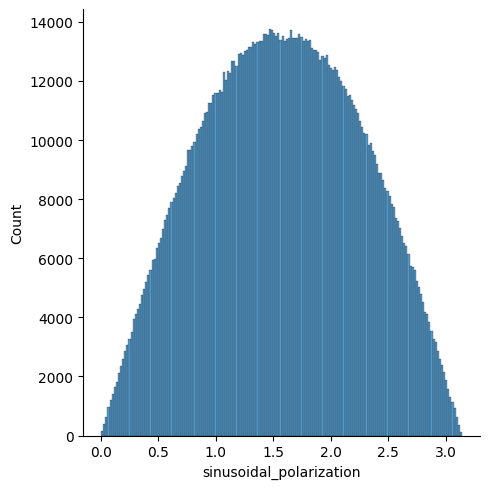

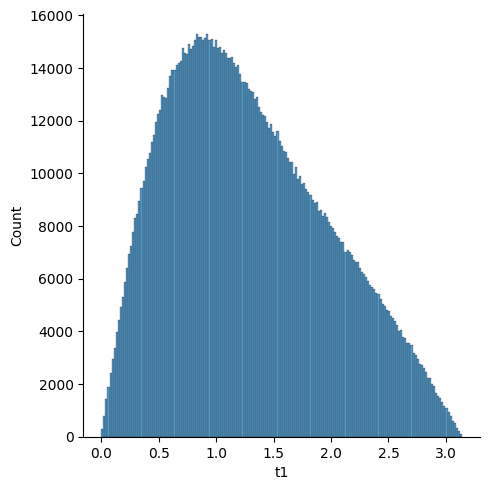

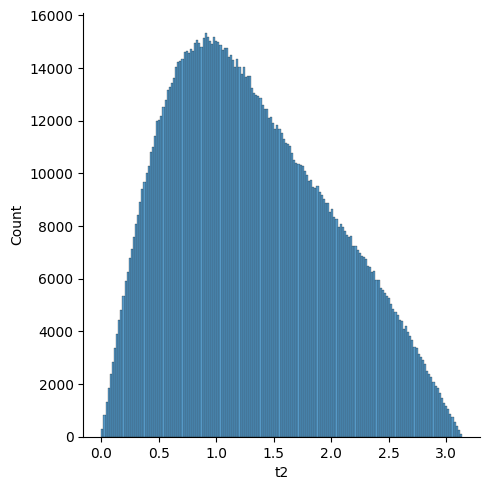

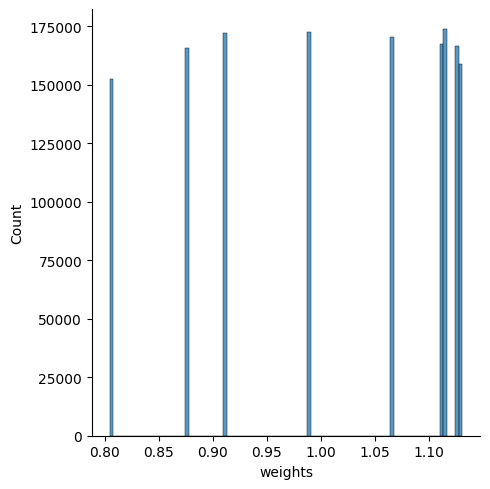

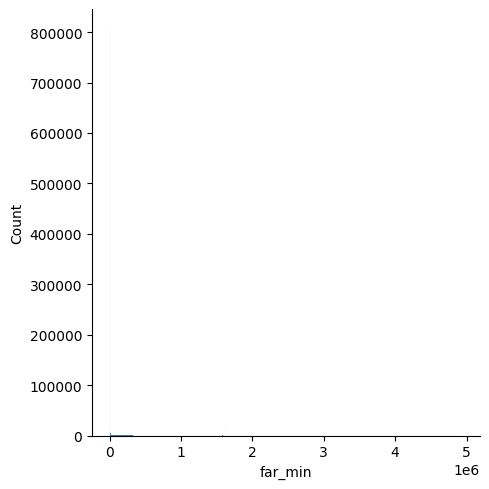

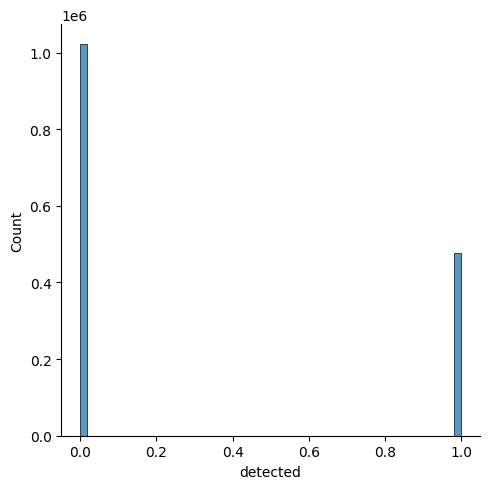

In [117]:
for col in data.columns:
    if "draw" not in col:
        sns.displot(data[col])
        plt.show()

In [140]:
# Assumed constants
H0cosmo = 67.9 # constants from https://dcc.ligo.org/public/0170/P2000318/011/o3b_catalog.pdf
Om0cosmo = 0.3065
cosmo = FlatLambdaCDM(H0=H0cosmo * u.km / u.s / u.Mpc, Om0=Om0cosmo)
speed_of_light = constants.c.to(u.km / u.s).value

def ddL_of_z(z, dL, H0):
    return dL / (1 + z) + speed_of_light * (1 + z) / (H0 * cosmo.efunc(z))

N_eval = 1000000
mass_grid = np.linspace(1, 100, N_eval)
spin_grid = np.linspace(0, 1, N_eval)
z_grid = np.linspace(0, 3, N_eval)
dVdz_grid = cosmo.differential_comoving_volume(z_grid).to(u.Gpc**3 / u.sr).value * 4 * np.pi

def primary_mass_pdf_interp(m1, min_m1=1.0, max_m1=1000.0):

    m = mass_grid.astype(float)
    logm = np.log(m)

    log_pdf = np.full_like(m, -np.inf)  # log(0)

    # --- piecewise definitions in log-space ---
    # [1, 3): flat
    sel = (m >= 1) & (m < 3)
    log_pdf[sel] = 0.0

    # [3, 8): (m/3)^(-4)
    sel = (m >= 3) & (m < 8)
    log_pdf[sel] = -4.0 * (logm[sel] - np.log(3.0))

    # [8, 50): continuity enforced explicitly
    sel = (m >= 8) & (m < 50)
    log_norm = -4.0 * (np.log(8.0) - np.log(3.0))
    log_pdf[sel] = log_norm - 1.0 * (logm[sel] - np.log(8.0))

    # [50, 200)
    sel = (m >= 50) & (m < 200)
    log_norm += -1.0 * (np.log(50.0) - np.log(8.0))
    log_pdf[sel] = log_norm - 4.0 * (logm[sel] - np.log(50.0))

    # [200, 1000)
    sel = (m >= 200) & (m < 1000)
    log_norm += -4.0 * (np.log(200.0) - np.log(50.0))
    log_pdf[sel] = log_norm - 1.0 * (logm[sel] - np.log(200.0))

    # Outside allowed range
    log_pdf[(m < min_m1) | (m > max_m1)] = -np.inf

    # --- exponentiate safely ---
    pdf = np.exp(log_pdf)

    # --- normalize robustly ---
    norm = np.trapezoid(pdf, m)
    if norm > 0:
        pdf /= norm

    # --- interpolate ---
    return interp1d(
        m, pdf,
        bounds_error=False,
        fill_value=0.0,
        assume_sorted=True
    )(m1)

def primary_mass_pdf(m1, min_m1=1.0, max_m1=1000.0):

    m = np.asarray(m1, dtype=float)
    logm = np.log(m, where=(m > 0), out=np.full_like(m, -np.inf))

    log_pdf = np.full_like(m, -np.inf)  # log(0)

    # --- piecewise definition in log-space ---

    # [1, 3): flat
    sel = (m >= 1) & (m < 3)
    log_pdf[sel] = 0.0

    # [3, 8): (m/3)^(-4)
    sel = (m >= 3) & (m < 8)
    log_pdf[sel] = -4.0 * (logm[sel] - np.log(3.0))

    # [8, 50)
    sel = (m >= 8) & (m < 50)
    log_norm = -4.0 * (np.log(8.0) - np.log(3.0))
    log_pdf[sel] = log_norm - (logm[sel] - np.log(8.0))

    # [50, 200)
    sel = (m >= 50) & (m < 200)
    log_norm += -1.0 * (np.log(50.0) - np.log(8.0))
    log_pdf[sel] = log_norm - 4.0 * (logm[sel] - np.log(50.0))

    # [200, 1000)
    sel = (m >= 200) & (m < 1000)
    log_norm += -4.0 * (np.log(200.0) - np.log(50.0))
    log_pdf[sel] = log_norm - (logm[sel] - np.log(200.0))

    # Outside bounds
    log_pdf[(m < min_m1) | (m > max_m1)] = -np.inf

    # --- exponentiate safely ---
    pdf = np.exp(log_pdf)

    # --- robust normalization ---
    # Sort for trapezoid stability
    idx = np.argsort(m)
    m_sorted = m[idx]
    pdf_sorted = pdf[idx]

    norm = np.trapezoid(pdf_sorted, m_sorted)
    if norm > 0:
        pdf /= norm

    return pdf


def secondary_mass_pdf(m2, m1, min_m2 = 1):

    pm2 = 2*m2 / (m1**2 - 1)
    support = (m2 >= min_m2) & (m2 <= m1)
    # should be properly normalized already I realize
    return np.where(support, pm2, 0.0)

def spin_pdf(s):

    ps = np.exp(-2*s**2)

    idx = np.argsort(s)
    s_sorted = s[idx]
    pdf_sorted = ps[idx]
    
    norm = np.trapezoid(pdf_sorted, s_sorted)
    if norm > 0:
        ps /= norm

    return ps

def cos_tilts_pdf(tilt):
    cos_tilt = np.cos(tilt)
    # should be normalized too given the definition
    pcost = (0.3 * ((1+cos_tilt)**3)/4 + 0.35)*np.sin(tilt)  # last summand is 0.7*1/2
    return pcost

def redshift_pdf(z, z_grid, dVdz_grid):
    num_grid = dVdz_grid
    den = np.trapezoid(num_grid, z_grid)
    num_grid /= den
    
    return interp1d(z_grid, num_grid, fill_value = 0, bounds_error = False)(z)

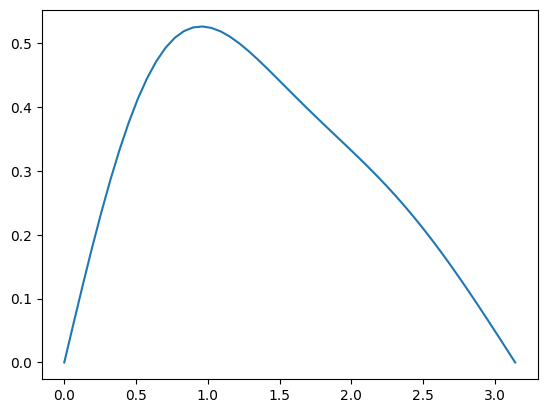

In [128]:
plt.plot(np.linspace(0, np.pi), cos_tilts_pdf(np.linspace(0, np.pi)))

### Confirm the individual parameters of the model

In [129]:
# m1
pm1 = primary_mass_pdf(data["m1_source"])
np.sum(np.isclose(data["p_draw_m1"], pm1, atol = 1e-4))

np.int64(1475420)

In [130]:
pm2 = secondary_mass_pdf(data["m2_source"], data["m1_source"])
np.sum(np.isclose(data["p_draw_m2"], pm2))

np.int64(1499244)

In [131]:
ps1 = spin_pdf(data["a1"])
np.sum(np.isclose(data["p_draw_a1"], ps1))

np.int64(1499244)

In [132]:
ps2 = spin_pdf(data["a2"])
np.sum(np.isclose(data["p_draw_a2"], ps2))

np.int64(1499244)

In [135]:
pt1 = cos_tilts_pdf(data["tilt1"])
np.sum(np.isclose(data["p_draw_tilt1"], pt1))

np.int64(1499244)

In [134]:
pt2 = cos_tilts_pdf(data["tilt2"])
np.sum(np.isclose(data["p_draw_tilt2"], pt2))

np.int64(1499244)

In [146]:
pz = redshift_pdf(data["redshift"], z_grid, dVdz_grid)
np.sum(np.isclose(data["p_draw_z"], pz, atol = 1e-5))

np.int64(1499244)

In [138]:
pphi1 = np.ones_like(data["phi1"]) / (2*np.pi)
np.sum(np.isclose(data["p_draw_phi1"], pphi1))

np.int64(1499244)

In [139]:
pphi2 = np.ones_like(data["phi2"]) / (2*np.pi)
np.sum(np.isclose(data["p_draw_phi2"], pphi2))

np.int64(1499244)

In [147]:
pra = np.ones_like(data["right_ascension"]) / (2*np.pi)
np.sum(np.isclose(data["p_draw_ra"], pra))

np.int64(1499244)

In [148]:
ppol = np.ones_like(data["polarization"]) / np.pi
np.sum(np.isclose(data["p_draw_pol"], ppol))

np.int64(1499244)

In [149]:
pdec = np.cos(data["declination"]) / 2
np.sum(np.isclose(data["p_draw_dec"], pdec))

np.int64(1499244)

In [159]:
pinc = np.sin(data["inclination"]) / 2
np.sum(np.isclose(data["p_draw_inc"], pinc))

np.int64(1499244)

In [160]:
def model_pdf_gwtc4(data, z_grid, dVdz_grid):

    pm1 = primary_mass_pdf(data["m1_source"])
    pm2 = secondary_mass_pdf(data["m2_source"], data["m1_source"])

    pa1 = spin_pdf(data["a1"])
    pa2 = spin_pdf(data["a2"])

    pt1 = cos_tilts_pdf(data["tilt1"])
    pt2 = cos_tilts_pdf(data["tilt2"])

    pz = redshift_pdf(data["redshift"], z_grid, dVdz_grid)

    pphi1 = np.ones_like(data["phi1"]) / (2*np.pi)
    pphi2 = np.ones_like(data["phi2"]) / (2*np.pi)

    pra = np.ones_like(data["right_ascension"]) / (2*np.pi)
    pdec = np.cos(data["declination"]) / 2

    ppol = np.ones_like(data["polarization"]) / np.pi
    pinc = np.sin(data["inclination"]) / 2

    return pm1*pm2*pa1*pa2*pz*pt1*pt2*pphi1*pphi2*pra*pdec*ppol*pinc

In [161]:
p_draw = model_pdf_gwtc4(data, z_grid, dVdz_grid)

In [171]:
np.sum(p_draw), np.sum(data["far_min"] < 1)/len(data)

(np.float64(0.002493335587741283), np.float64(0.31776415313317913))

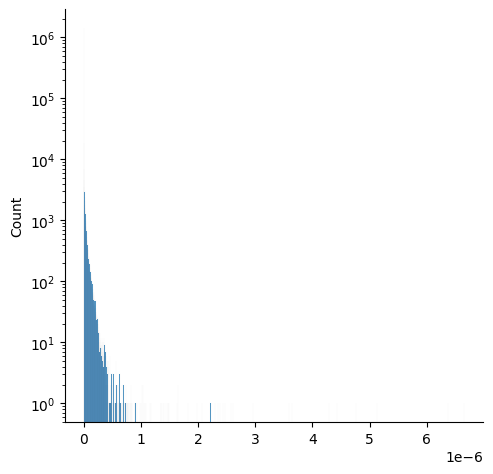

In [165]:
sns.displot(p_draw)
plt.tight_layout()
plt.yscale("log")
plt.show()